# RQ5: Can customer demographic features (Age, Gender) improve sales revenue predictions when combined with marketing features?
**Dataset:** Marketing and Product Performance Dataset (Kaggle)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
print('Ready.')

Ready.


In [25]:
# ── LOAD DATASET ──────────────────────────────────────────────────────────────
df = pd.read_csv('marketing_and_product_performance.csv')
df = df.dropna(subset=['Revenue_Generated'])
drop_cols = [c for c in df.columns if 'id' in c.lower() or 'name' in c.lower()]
df.drop(columns=drop_cols, errors='ignore', inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    else:
        df[col].fillna(df[col].median(), inplace=True)

target = 'Revenue_Generated'
# Find demographic columns
age_col    = next((c for c in df.columns if 'age' in c.lower()), None)
gender_col = next((c for c in df.columns if 'gender' in c.lower()), None)
demo_cols  = [c for c in [age_col, gender_col] if c is not None]
print(f'Demographic cols: {demo_cols}')

all_features = [c for c in df.columns if c != target]
non_demo     = [c for c in all_features if c not in demo_cols]

Demographic cols: []


In [26]:
# ── TRAIN: With vs Without Demographics ───────────────────────────────────────
def train_eval(feature_set, label):
    X = df[feature_set]
    y = df[target]
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    Xt, Xv, yt, yv = train_test_split(X_sc, y, test_size=0.2, random_state=42)
    m = GradientBoostingRegressor(n_estimators=150, random_state=42)
    m.fit(Xt, yt)
    pr = m.predict(Xv)
    r2   = r2_score(yv, pr)
    rmse = np.sqrt(mean_squared_error(yv, pr))
    mae  = mean_absolute_error(yv, pr)
    cv   = cross_val_score(m, X_sc, y, cv=5, scoring='r2').mean()
    print(f'{label}: R²={r2:.4f}  RMSE={rmse:.2f}  MAE={mae:.2f}  CV-R²={cv:.4f}')
    return {'Feature Set': label, 'R²': round(r2,4), 'RMSE': round(rmse,2),
            'MAE': round(mae,2), 'CV_R²': round(cv,4), 'Num_Features': len(feature_set)}

results = []
results.append(train_eval(non_demo, 'Without Demographics'))
if demo_cols:
    results.append(train_eval(all_features, 'With Demographics'))
    if age_col:
        results.append(train_eval(non_demo + [age_col], 'With Age Only'))
    if gender_col:
        results.append(train_eval(non_demo + [gender_col], 'With Gender Only'))

table_51 = pd.DataFrame(results)
table_51.to_csv('Table_5_1_Demographics_Impact.csv', index=False)
print('Table 5.1 saved.')
table_51

Without Demographics: R²=-0.0124  RMSE=28731.71  MAE=24842.64  CV-R²=-0.0201
Table 5.1 saved.


,Feature Set,R²,RMSE,MAE,CV_R²,Num_Features
0,Without Demographics,-0.0124,28731.71,24842.64,-0.0201,11


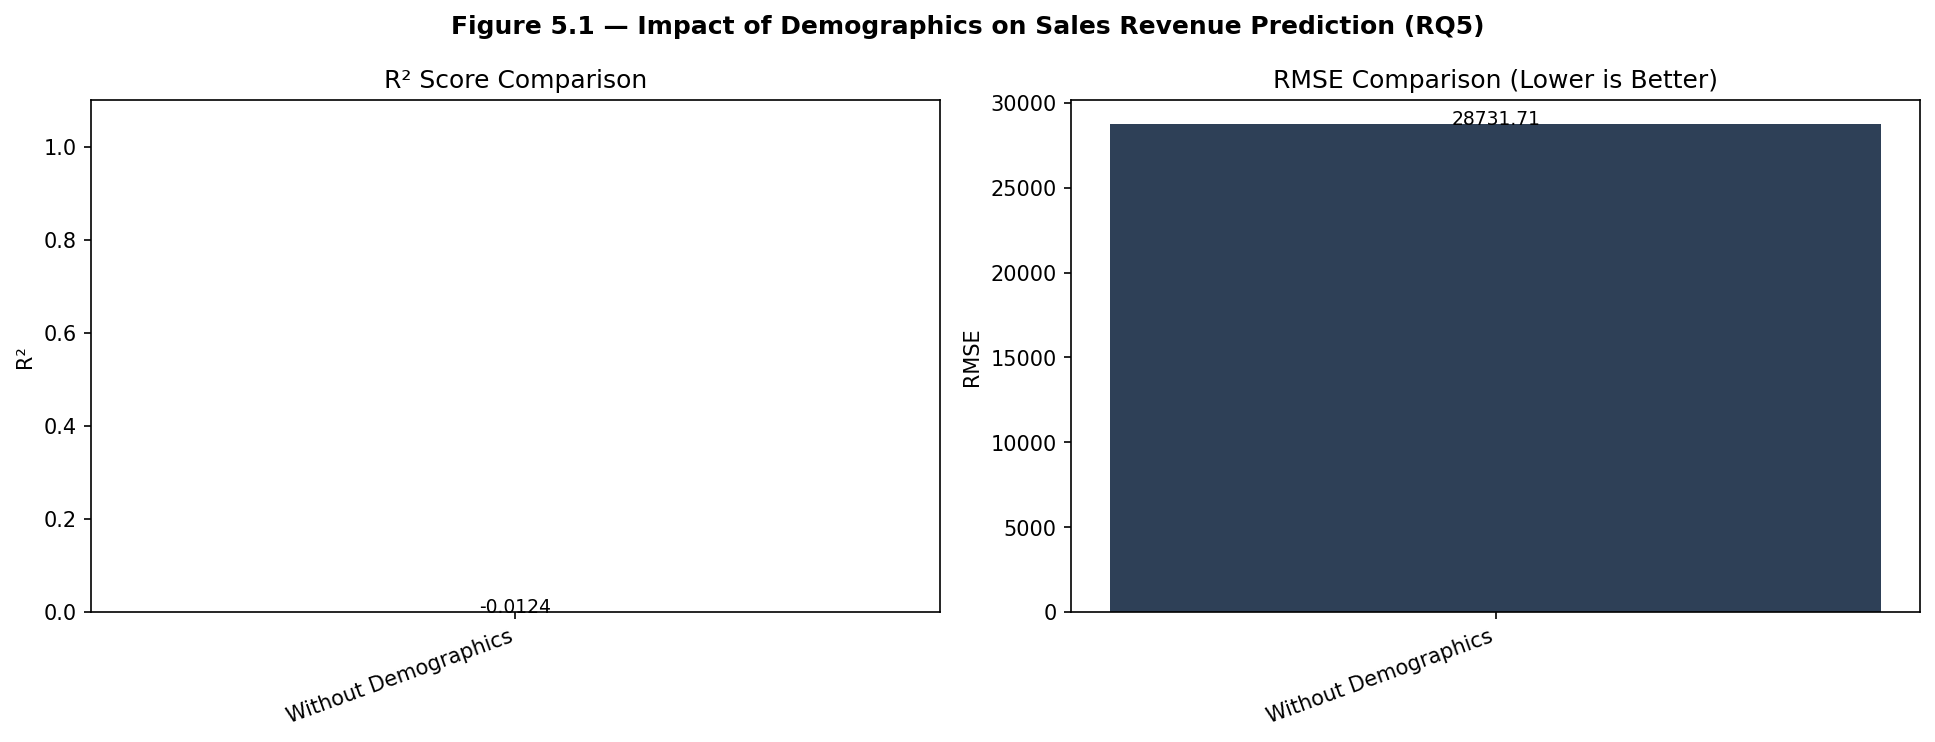

Figure 5.1 saved.


In [27]:
# ── FIGURE 5.1 — R² Improvement with Demographics ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 5.1 — Impact of Demographics on Sales Revenue Prediction (RQ5)', fontweight='bold')

colors = ['#2E4057', '#048A81', '#E07A5F', '#F2CC8F'][:len(table_51)]
axes[0].bar(table_51['Feature Set'], table_51['R²'], color=colors)
axes[0].set_title('R² Score Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.1)
for i, v in enumerate(table_51['R²']):
    axes[0].text(i, v+0.01, f'{v:.4f}', ha='center', fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

axes[1].bar(table_51['Feature Set'], table_51['RMSE'], color=colors)
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_ylabel('RMSE')
for i, v in enumerate(table_51['RMSE']):
    axes[1].text(i, v+0.5, f'{v:.2f}', ha='center', fontsize=9)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('Figure_5_1_Demographics_Impact.pdf', bbox_inches='tight')
plt.show()
print('Figure 5.1 saved.')

In [30]:
# ── FIGURE 5.2 — Revenue by Age Group and Gender ─────────────────────────────
# Reload raw for visualization
df_raw = pd.read_csv('marketing_and_product_performance.csv')

age_col_raw    = next((c for c in df_raw.columns if 'age' in c.lower()), None)
gender_col_raw = next((c for c in df_raw.columns if 'gender' in c.lower()), None)

if age_col_raw:
    df_raw['Age_Group'] = pd.cut(df_raw[age_col_raw], bins=[0,25,35,45,55,100],
                                  labels=['<25','25-35','35-45','45-55','55+'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Figure 5.2 — Revenue by Age Group and Gender (RQ5)', fontweight='bold')

    age_rev = df_raw.groupby('Age_Group')['Revenue_Generated'].mean()
    axes[0].bar(age_rev.index.astype(str), age_rev.values, color='#2E4057')
    axes[0].set_title('Mean Revenue by Age Group')
    axes[0].set_ylabel('Mean Sales Revenue')
    axes[0].set_xlabel('Age Group')

    if gender_col_raw:
        gend_rev = df_raw.groupby(gender_col_raw)['Revenue_Generated'].mean()
        axes[1].bar(gend_rev.index.astype(str), gend_rev.values,
                    color=['#048A81','#E07A5F','#F2CC8F'][:len(gend_rev)])
        axes[1].set_title('Mean Revenue by Gender')
        axes[1].set_ylabel('Mean Sales Revenue')
        axes[1].set_xlabel('Gender')

    plt.tight_layout()
    plt.savefig('Figure_5_2_Revenue_Age_Gender.pdf', bbox_inches='tight')
    plt.show()
    print('Figure 5.2 saved.')

## RQ5 Summary
Table 5.1 quantifies whether adding Age and Gender columns improves model R². If the improvement is small (<0.005), demographic features add limited predictive value. Figures 5.1 and 5.2 visualize the magnitude of improvement and revenue patterns across demographic groups.